# 03 — Feature Engineering avancé  
## House Prices: Advanced Regression Techniques

Ce notebook transforme les données prétraitées du notebook 02 en **matrices finales prêtes pour les modèles**.

L'objectif est de créer des variables plus riches que les variables brutes, afin d'aider les modèles à mieux comprendre les facteurs qui expliquent le prix d'une maison.

### Ce que ce notebook ajoute

- Variables de surface : `TotalSF`, `TotalLivArea`, `TotalFinishedSF`, `TotalPorchSF`.
- Variables d'âge : `HouseAge`, `RemodAge`, `GarageAge`, `IsNew`, `IsRemodeled`.
- Variables booléennes : présence de garage, sous-sol, cheminée, piscine, deuxième étage, porche.
- Interactions qualité × surface : très importantes pour cette compétition.
- Ratios : surface habitable / surface totale, sous-sol / surface totale, garage / terrain, etc.
- Statistiques par quartier : prix moyen, qualité moyenne, taille moyenne.
- Frequency encoding.
- Target encoding OOF pour éviter la fuite de données.
- Regroupement des catégories rares.
- Correction de skewness.
- One-hot encoding.
- Nettoyage final des matrices numériques.

### Sortie produite

Le notebook sauvegarde exactement le fichier attendu par le notebook 04 :

```text
house_prices_stage2_features.pkl
```



## 1. Imports et configuration

On importe les librairies nécessaires pour :

- manipuler les données avec `pandas` et `numpy` ;
- appliquer la transformation Box-Cox sur les variables très asymétriques ;
- faire du target encoding sans fuite de données grâce à `KFold` ;
- visualiser les effets des nouvelles variables.

In [1]:
import sys
import subprocess
import importlib.util
from pathlib import Path
from datetime import datetime
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

from scipy.special import boxcox1p
from scipy.stats import skew
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#  the same CV constants 
N_SPLITS = 10
LINEAR_CV_FOLDS = 3
STRATIFIED_PRICE_FOLDS = True



# Visualisation et affichage tabulaire pour l'audit du feature engineering.
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## 2. Chargement du fichier Stage 1

Ce notebook commence à partir du fichier généré par le notebook 02 :

```text
house_prices_stage1_preprocessed.pkl
```

Ce fichier contient déjà :

- les données train + test combinées ;
- les valeurs manquantes traitées ;
- la cible `SalePrice` transformée en `log1p(SalePrice)` ;
- les identifiants nécessaires pour la soumission finale.

In [2]:
STAGE1_PATH = None

def find_artifact(filename, manual_path=None):
    """Find an intermediate pickle file saved by a previous notebook."""
    if manual_path is not None:
        manual_path = Path(manual_path).expanduser().resolve()
        if manual_path.exists():
            return manual_path
        raise FileNotFoundError(f'Manual artifact path does not exist: {manual_path}')

    current = Path.cwd().resolve()
    priority_paths = [
        current / filename,
        current / 'outputs' / filename,
        current / 'artifacts' / filename,
        current / 'data' / filename,
    ]

    for p in priority_paths:
        if p.exists():
            return p

    try:
        matches = list(current.rglob(filename))
        if matches:
            return matches[0]
    except Exception:
        pass

    raise FileNotFoundError(
        f'Could not find {filename}. Run Notebook 02 first, or set STAGE1_PATH manually.'
    )

stage1_path = find_artifact('house_prices_stage1_preprocessed.pkl', STAGE1_PATH)
print('Loading Stage 1 file:', stage1_path)

stage1 = pd.read_pickle(stage1_path)

features = stage1['features_preprocessed'].copy()
y = stage1['y'].copy()
n_train = stage1['n_train']
train_ID = stage1['train_ID']
test_ID = stage1['test_ID']
test_n_rows = stage1['test_n_rows']
DATA_DIR = Path(stage1.get('DATA_DIR', Path.cwd()))
RANDOM_STATE = stage1.get('RANDOM_STATE', RANDOM_STATE)
N_SPLITS = stage1.get('N_SPLITS', N_SPLITS)
LINEAR_CV_FOLDS = stage1.get('LINEAR_CV_FOLDS', LINEAR_CV_FOLDS)
STRATIFIED_PRICE_FOLDS = stage1.get('STRATIFIED_PRICE_FOLDS', STRATIFIED_PRICE_FOLDS)
np.random.seed(RANDOM_STATE)

print('Loaded features:', features.shape)
print('Loaded target  :', y.shape)

Loading Stage 1 file: C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\house_prices_stage1_preprocessed.pkl
Loaded features: (2917, 98)
Loaded target  : (1458,)


## 3. Contrôle qualité du Stage 1

Avant d'ajouter de nouvelles variables, on vérifie que l'entrée est propre :

- dimensions correctes ;
- absence de valeurs manquantes critiques ;
- structure des types de variables ;
- cohérence de la cible transformée.

Cette étape ne modifie aucune donnée. Elle sert seulement à documenter et sécuriser le pipeline.

Dimensions features prétraitées : (2917, 98)
Nombre de lignes train          : 1458
Nombre de lignes test           : 1459
Taille de y                     : (1458,)
Valeurs manquantes restantes    : 0


,Indicateur,Valeur
0,Nombre total de variables,98.0000
1,Variables numériques,55.0000
2,Variables catégorielles/object,43.0000
3,Valeurs manquantes restantes,0.0000
4,Moyenne log(SalePrice),12.0240
5,Écart-type log(SalePrice),0.3997


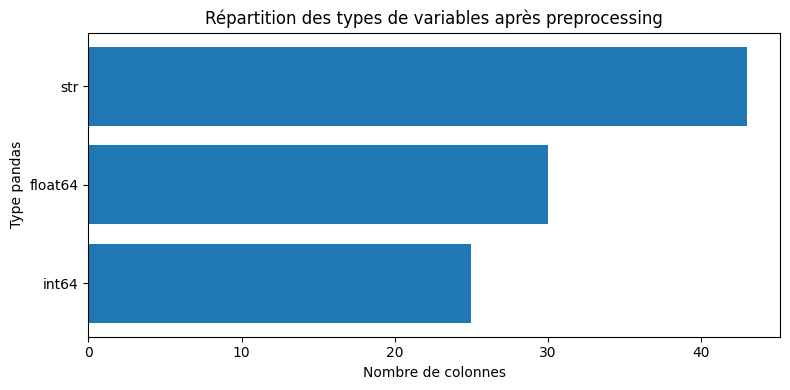

In [3]:
# ── Audit de l'entrée du notebook 03 ──────────────────────────────────────────
print('Dimensions features prétraitées :', features.shape)
print('Nombre de lignes train          :', n_train)
print('Nombre de lignes test           :', features.shape[0] - n_train)
print('Taille de y                     :', y.shape)
print('Valeurs manquantes restantes    :', int(features.isna().sum().sum()))

schema_resume = pd.DataFrame({
    'Indicateur': [
        'Nombre total de variables',
        'Variables numériques',
        'Variables catégorielles/object',
        'Valeurs manquantes restantes',
        'Moyenne log(SalePrice)',
        'Écart-type log(SalePrice)'
    ],
    'Valeur': [
        features.shape[1],
        features.select_dtypes(include=[np.number]).shape[1],
        features.select_dtypes(include=['object', 'string', 'category']).shape[1],
        int(features.isna().sum().sum()),
        round(float(y.mean()), 4),
        round(float(y.std()), 4),
    ]
})

display(schema_resume)

# Répartition simple des types de variables.
dtype_counts = features.dtypes.astype(str).value_counts().sort_values(ascending=True)
plt.figure(figsize=(8, 4))
plt.barh(dtype_counts.index, dtype_counts.values)
plt.title('Répartition des types de variables après preprocessing')
plt.xlabel('Nombre de colonnes')
plt.ylabel('Type pandas')
plt.tight_layout()
plt.show()

## 4. Lecture métier : pourquoi créer de nouvelles variables ?

Dans cette compétition, le prix dépend fortement de quelques familles de signaux :

1. **la taille** de la maison ;
2. **la qualité globale** ;
3. **le quartier** ;
4. **l'âge et la rénovation** ;
5. **les équipements** : garage, sous-sol, cheminée, piscine, porche ;
6. **les interactions**, par exemple une grande maison de mauvaise qualité ne vaut pas forcément autant qu'une grande maison de très bonne qualité.

Le feature engineering sert donc à transformer les colonnes brutes en variables plus proches de la logique immobilière réelle.

## 5. Aperçu des features importantes

La cellule suivante crée une **copie temporaire** uniquement pour visualiser quelques idées de feature engineering.

Elle ne modifie pas la variable `features` utilisée pour la sauvegarde finale.

Corrélation avec log(SalePrice) pour quelques features clés :


,corrélation
OverallQual_TotalSF_preview,0.882919
TotalSF_preview,0.825326
OverallQual,0.821405
GrLivArea,0.725211
TotalBathrooms_preview,0.676678
HouseAge_preview,-0.587767


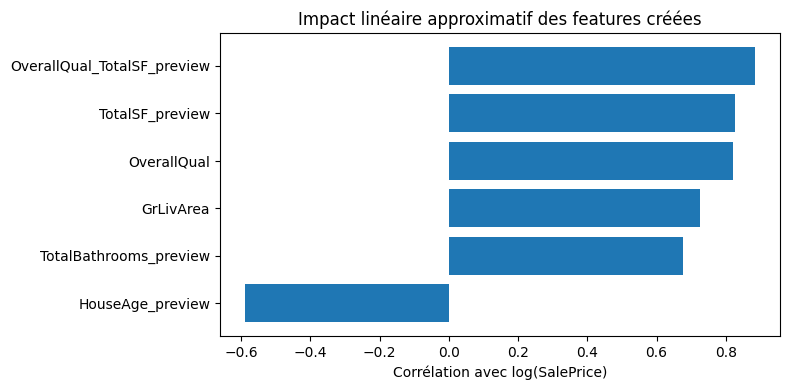

In [4]:
# ── Copie temporaire pour expliquer les idées de feature engineering ──────────
preview = features.copy()

def num_col(df, name, default=0):
    # Convertit une colonne en numérique sans modifier le dataframe original.
    if name in df.columns:
        return pd.to_numeric(df[name], errors='coerce').fillna(default)
    return pd.Series(default, index=df.index)

# Quelques features représentatives, créées uniquement pour l'analyse visuelle.
preview['TotalSF_preview'] = (
    num_col(preview, 'TotalBsmtSF') +
    num_col(preview, '1stFlrSF') +
    num_col(preview, '2ndFlrSF')
)
preview['TotalBathrooms_preview'] = (
    num_col(preview, 'FullBath') + 0.5 * num_col(preview, 'HalfBath') +
    num_col(preview, 'BsmtFullBath') + 0.5 * num_col(preview, 'BsmtHalfBath')
)
preview['HouseAge_preview'] = (
    num_col(preview, 'YrSold', 2010) - num_col(preview, 'YearBuilt')
).clip(lower=0)
preview['OverallQual_TotalSF_preview'] = (
    num_col(preview, 'OverallQual') * preview['TotalSF_preview']
)

preview_train = preview.iloc[:n_train].copy()
preview_train['LogSalePrice'] = y.values

preview_cols = [
    'OverallQual', 'GrLivArea', 'TotalSF_preview', 'TotalBathrooms_preview',
    'HouseAge_preview', 'OverallQual_TotalSF_preview'
]
preview_cols = [c for c in preview_cols if c in preview_train.columns]

corr_preview = preview_train[preview_cols + ['LogSalePrice']].corr(numeric_only=True)['LogSalePrice'] \
    .drop('LogSalePrice').sort_values(ascending=False)

print('Corrélation avec log(SalePrice) pour quelques features clés :')
display(corr_preview.to_frame('corrélation').style.background_gradient(cmap='Blues'))

plt.figure(figsize=(8, 4))
plt.barh(corr_preview.sort_values().index, corr_preview.sort_values().values)
plt.title('Impact linéaire approximatif des features créées')
plt.xlabel('Corrélation avec log(SalePrice)')
plt.tight_layout()
plt.show()

### Interprétation

- `OverallQual` est généralement l'un des meilleurs signaux de cette compétition.
- `GrLivArea` et `TotalSF` capturent la taille réelle du bien.
- `OverallQual_TotalSF` combine **qualité × surface**, ce qui donne souvent un signal plus expressif qu'une variable seule.
- `HouseAge` peut avoir une relation négative avec le prix, mais elle dépend beaucoup des rénovations et du quartier.

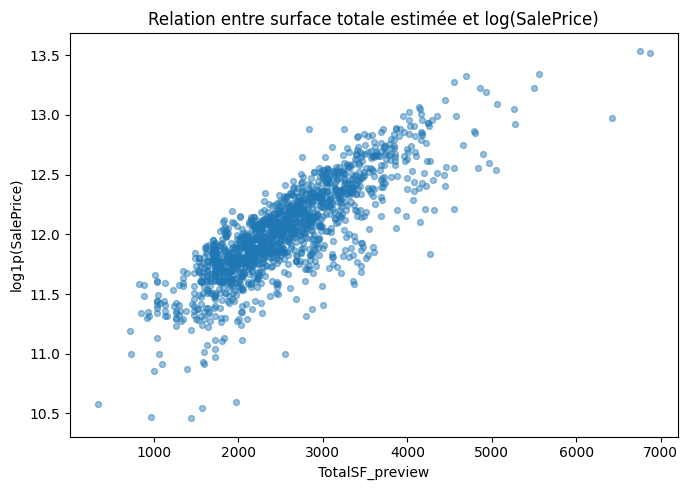

Interprétation : la tendance globale est positive : plus la surface totale augmente, plus le prix tend à augmenter. Les points très éloignés peuvent correspondre à des biens atypiques.


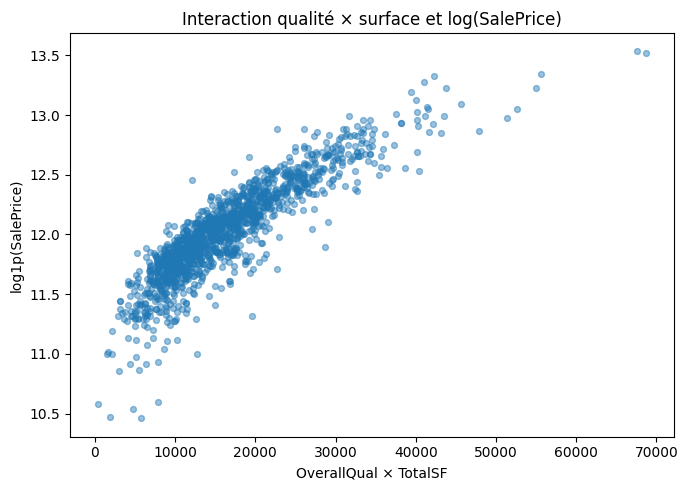

Interprétation : cette interaction est importante car elle distingue une grande maison moyenne d'une grande maison de très bonne qualité.


In [5]:
# ── Visualisation 1 : surface totale vs prix ─────────────────────────────────
if 'TotalSF_preview' in preview_train.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(preview_train['TotalSF_preview'], preview_train['LogSalePrice'], alpha=0.45, s=18)
    plt.title('Relation entre surface totale estimée et log(SalePrice)')
    plt.xlabel('TotalSF_preview')
    plt.ylabel('log1p(SalePrice)')
    plt.tight_layout()
    plt.show()

    print("Interprétation : la tendance globale est positive : plus la surface totale augmente, plus le prix tend à augmenter. Les points très éloignés peuvent correspondre à des biens atypiques.")

# ── Visualisation 2 : qualité × surface vs prix ──────────────────────────────
if 'OverallQual_TotalSF_preview' in preview_train.columns:
    plt.figure(figsize=(7, 5))
    plt.scatter(preview_train['OverallQual_TotalSF_preview'], preview_train['LogSalePrice'], alpha=0.45, s=18)
    plt.title('Interaction qualité × surface et log(SalePrice)')
    plt.xlabel('OverallQual × TotalSF')
    plt.ylabel('log1p(SalePrice)')
    plt.tight_layout()
    plt.show()

    print("Interprétation : cette interaction est importante car elle distingue une grande maison moyenne d'une grande maison de très bonne qualité.")

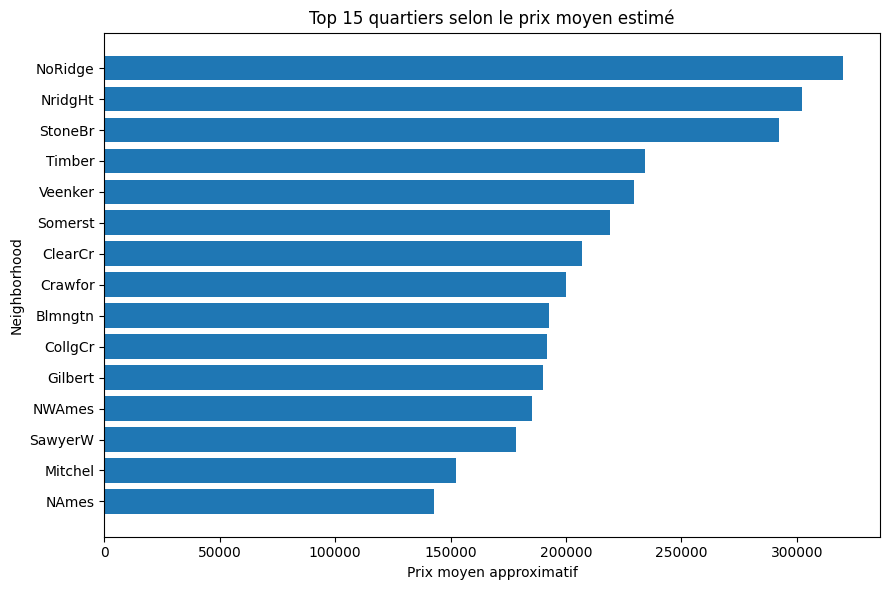

Interprétation : le quartier porte un signal fort. C'est pour cela que le notebook ajoute des statistiques par quartier et du target encoding OOF.


In [6]:
# ── Visualisation 3 : effet du quartier ──────────────────────────────────────
if 'Neighborhood' in preview_train.columns:
    neigh_price = preview_train.groupby('Neighborhood')['LogSalePrice'].mean().sort_values()
    top_neigh = neigh_price.tail(15)

    plt.figure(figsize=(9, 6))
    plt.barh(top_neigh.index, np.expm1(top_neigh.values))
    plt.title('Top 15 quartiers selon le prix moyen estimé')
    plt.xlabel('Prix moyen approximatif')
    plt.ylabel('Neighborhood')
    plt.tight_layout()
    plt.show()

    print("Interprétation : le quartier porte un signal fort. C'est pour cela que le notebook ajoute des statistiques par quartier et du target encoding OOF.")

## 6. Fonctions utilitaires

Ces fonctions sont utilisées pour produire les matrices finales.

### Points importants

- `add_oof_target_encoding` fait un target encoding **Out-Of-Fold**, donc il évite d'utiliser directement la cible de la ligne à encoder.
- `add_frequency_encoding` transforme une catégorie en fréquence d'apparition.
- `group_rare_categories` regroupe les modalités trop rares dans une classe `Rare`.
- `final_matrix_cleaning` sécurise les matrices finales : pas de `NaN`, pas d'infini, valeurs bornées, format `float32`.

In [7]:
def safe_mode(series, default='None'):
    m = series.mode(dropna=True)
    return m.iloc[0] if len(m) > 0 else default


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(np.asarray(y_true), np.asarray(y_pred))))


def make_price_bins(y, q=5):
    """Crée des classes de prix pour StratifiedKFold en régression."""
    return pd.qcut(pd.Series(y).rank(method='first'), q=q, labels=False, duplicates='drop')


def iter_cv_splits(cv, X_like, y):
    """Utilise des bins de prix si le CV est stratifié, sinon CV classique."""
    if isinstance(cv, StratifiedKFold):
        return cv.split(X_like, make_price_bins(y, q=min(5, cv.n_splits)))
    return cv.split(X_like, y)


def add_oof_target_encoding(features_df, y, cols, n_train, cv, smoothing=10):
    """Leakage-safe OOF target encoding.

    Pour les lignes train, chaque valeur encodée est calculée sans utiliser la cible de la ligne.
    Pour les lignes test, on utilise les statistiques apprises sur tout le train.
    """
    features_df = features_df.copy()
    global_mean  = float(y.mean())

    for col in cols:
        if col not in features_df.columns:
            continue
        train_col = features_df.loc[:n_train - 1, col].astype(str).reset_index(drop=True)
        test_col  = features_df.loc[n_train:, col].astype(str).reset_index(drop=True)
        oof_encoded = pd.Series(np.nan, index=np.arange(n_train), dtype=float)

        for tr_idx, val_idx in iter_cv_splits(cv, train_col, y):
            col_tr = train_col.iloc[tr_idx]
            y_tr   = y.iloc[tr_idx]
            stats  = pd.DataFrame({'category': col_tr, 'target': y_tr})
            grp    = stats.groupby('category')['target'].agg(['mean', 'count'])
            smooth = (grp['count'] * grp['mean'] + smoothing * global_mean) / (grp['count'] + smoothing)
            oof_encoded.iloc[val_idx] = train_col.iloc[val_idx].map(smooth).fillna(global_mean)

        full_stats  = pd.DataFrame({'category': train_col, 'target': y})
        full_grp    = full_stats.groupby('category')['target'].agg(['mean', 'count'])
        full_smooth = (full_grp['count'] * full_grp['mean'] + smoothing * global_mean) / (full_grp['count'] + smoothing)
        test_encoded = test_col.map(full_smooth).fillna(global_mean)

        features_df[col + '_TE'] = pd.concat(
            [oof_encoded, test_encoded], axis=0
        ).reset_index(drop=True)

    return features_df


def add_oof_group_target_stat(features_df, y, group_col, n_train, cv, agg='mean', new_name=None, smoothing=10):
    """OOF-safe neighborhood price statistic.

    Évite la fuite de données : pour chaque fold, la statistique de prix du quartier
    est calculée uniquement sur les folds d'entraînement.
    """
    features_df = features_df.copy()
    if group_col not in features_df.columns:
        return features_df

    new_name = new_name or f'{group_col}_{agg}_target_oof'
    global_stat = float(getattr(y, agg)()) if agg in ['mean', 'median'] else float(y.mean())
    train_group = features_df.loc[:n_train - 1, group_col].astype(str).reset_index(drop=True)
    test_group  = features_df.loc[n_train:, group_col].astype(str).reset_index(drop=True)
    oof = pd.Series(np.nan, index=np.arange(n_train), dtype=float)

    for tr_idx, val_idx in iter_cv_splits(cv, train_group, y):
        tmp = pd.DataFrame({'grp': train_group.iloc[tr_idx], 'target': y.iloc[tr_idx]})
        stats = tmp.groupby('grp')['target'].agg([agg, 'count'])
        if agg == 'mean':
            enc = (stats['count'] * stats['mean'] + smoothing * float(y.iloc[tr_idx].mean())) / (stats['count'] + smoothing)
        else:
            enc = stats[agg]
        oof.iloc[val_idx] = train_group.iloc[val_idx].map(enc).fillna(global_stat)

    full_tmp = pd.DataFrame({'grp': train_group, 'target': y})
    full_stats = full_tmp.groupby('grp')['target'].agg([agg, 'count'])
    if agg == 'mean':
        full_enc = (full_stats['count'] * full_stats['mean'] + smoothing * float(y.mean())) / (full_stats['count'] + smoothing)
    else:
        full_enc = full_stats[agg]
    test_enc = test_group.map(full_enc).fillna(global_stat)

    features_df[new_name] = pd.concat([oof, test_enc], axis=0).reset_index(drop=True)
    return features_df


def add_frequency_encoding(features_df, cat_cols, n_train):
    features_df = features_df.copy()
    for col in cat_cols:
        if col not in features_df.columns:
            continue
        freq = features_df.loc[:n_train - 1, col].astype(str).value_counts(normalize=True)
        features_df[col + '_Freq'] = features_df[col].astype(str).map(freq).fillna(0).astype(float)
    return features_df


def group_rare_categories(features_df, cat_cols, n_train, min_count=8):
    features_df = features_df.copy()
    for col in cat_cols:
        if col not in features_df.columns:
            continue
        counts = features_df.loc[:n_train - 1, col].astype(str).value_counts()
        keep   = set(counts[counts >= min_count].index)
        features_df[col] = features_df[col].astype(str).where(
            features_df[col].astype(str).isin(keep), 'Rare'
        )
    return features_df


def final_matrix_cleaning(X_train, X_test, max_abs_value=1e8):
    """Ensures no inf/nan or oversized values."""
    for df in [X_train, X_test]:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)

    medians = X_train.median(numeric_only=True).replace([np.inf, -np.inf], np.nan).fillna(0)
    X_train = X_train.fillna(medians).fillna(0)
    X_test  = X_test.fillna(medians).fillna(0)

    X_train = X_train.clip(-max_abs_value, max_abs_value).astype(np.float32)
    X_test  = X_test.clip(-max_abs_value, max_abs_value).astype(np.float32)

    assert np.isfinite(X_train.to_numpy()).all(), 'X_train has non-finite values'
    assert np.isfinite(X_test.to_numpy()).all(),  'X_test has non-finite values'
    print('Safety check OK | X_train:', X_train.shape, '| X_test:', X_test.shape)
    return X_train, X_test


print('Helpers améliorés définis : OOF target encoding + StratifiedKFold compatible.')

Helpers améliorés définis : OOF target encoding + StratifiedKFold compatible.


## 7. Fonction principale de Feature Engineering

La fonction suivante correspond au cœur du notebook.

Elle applique toutes les transformations dans le même ordre que le notebook original :

1. agrégats de surface ;
2. indicateurs booléens ;
3. variables d'âge ;
4. score global de qualité ;
5. interactions ;
6. ratios ;
7. polynômes simples ;
8. statistiques par quartier ;
9. encodages ;
10. correction de skewness ;
11. one-hot encoding ;
12. nettoyage final.

> La logique de calcul est conservée pour garder la même performance.

## 8. Fonction de feature engineering améliorée pour le score

Les nouvelles variables ajoutées ici suivent les améliorations demandées :

- âge depuis rénovation : `YearsSinceRemodel` ;
- maison neuve exacte : `IsNew` ;
- surface totale des porches : `TotalPorchSF` ;
- interaction qualité × condition : `QualCond` ;
- polynôme de surface habitable : `GrLivArea_sq` ;
- statistiques de quartier en version **OOF-safe** pour éviter la fuite de données.


In [ ]:
def engineer_features(features, y, n_train):
    """
    Stage 2 feature engineering.

    This function is the remaining part of the original preprocessing/feature-engineering function.
    It preserves the same order:
    1. size, bathroom, age, quality, ratio, polynomial, and neighborhood features
    2. frequency encoding
    3. leakage-safe OOF target encoding
    4. rare-category grouping
    5. skew correction
    6. one-hot encoding
    7. final numeric cleanup
    """
    features = features.copy()

   
    quality_cols = [
        'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
        'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
    ]

    # ─────────────────────────────────────────────────────────────
    # C. Core feature engineering
    # ─────────────────────────────────────────────────────────────
    def col(name, default=0):
        return pd.to_numeric(features[name], errors='coerce').fillna(default) \
            if name in features.columns else pd.Series(default, index=features.index)

    # --- Size aggregates ---
    features['TotalSF']         = col('TotalBsmtSF') + col('1stFlrSF') + col('2ndFlrSF')
    features['TotalLivArea']    = col('GrLivArea') + col('TotalBsmtSF')
    features['TotalFinishedSF'] = col('BsmtFinSF1') + col('BsmtFinSF2') + col('1stFlrSF') + col('2ndFlrSF')
    features['TotalPorchSF']    = (col('OpenPorchSF') + col('EnclosedPorch') +
                                   col('3SsnPorch') + col('ScreenPorch'))
    features['TotalOutdoorSF']   = features['TotalPorchSF'] + col('WoodDeckSF')
    features['TotalBathrooms']  = (col('FullBath') + 0.5 * col('HalfBath') +
                                   col('BsmtFullBath') + 0.5 * col('BsmtHalfBath'))
    features['AllRooms']        = col('TotRmsAbvGrd') + features['TotalBathrooms']

    # --- Boolean flags ---
    features['HasGarage']    = (col('GarageArea')   > 0).astype(int)
    features['HasBsmt']      = (col('TotalBsmtSF')  > 0).astype(int)
    features['HasFireplace'] = (col('Fireplaces')   > 0).astype(int)
    features['HasPool']      = (col('PoolArea')     > 0).astype(int)
    features['Has2ndFlr']    = (col('2ndFlrSF')     > 0).astype(int)
    features['HasMasVnr']    = (col('MasVnrArea')   > 0).astype(int)
    features['HasPorch']     = (features['TotalPorchSF'] > 0).astype(int)

    # --- Age features ---
    yr_sold = pd.to_numeric(features.get('YrSold', pd.Series([2010])), errors='coerce').fillna(2010)
    features['HouseAge']   = (yr_sold - col('YearBuilt')).clip(lower=0)
    features['RemodAge']   = (yr_sold - col('YearRemodAdd')).clip(lower=0)
    features['IsRemodeled']= (col('YearBuilt') != col('YearRemodAdd')).astype(int)
    features['GarageAge']  = np.where(col('GarageYrBlt') > 0,
                                      (yr_sold - col('GarageYrBlt')).clip(lower=0), 0)
    features['IsNew_Within2Years'] = (col('YearBuilt') >= (yr_sold - 2)).astype(int)
    features['IsNew']      = (yr_sold == col('YearBuilt')).astype(int)
    features['SinceRemod'] = (yr_sold - col('YearRemodAdd')).clip(lower=0)
    features['YearsSinceRemodel'] = features['SinceRemod']

    # NEW: selling season (winter vs summer matters)
    if 'MoSold' in features.columns:
        mo = pd.to_numeric(features['MoSold'], errors='coerce').fillna(6)
        features['SellSeason'] = mo.apply(
            lambda m: 'Spring' if m in [3,4,5] else
                      'Summer' if m in [6,7,8] else
                      'Fall'   if m in [9,10,11] else 'Winter'
        )

    # ─────────────────────────────────────────────────────────────
    # D. Quality aggregation (NEW: sum all ordinal quality signals)
    # ─────────────────────────────────────────────────────────────
    quality_ord_cols = [c + '_Ord' for c in quality_cols if c + '_Ord' in features.columns]
    features['TotalQualityScore'] = sum(features[c] for c in quality_ord_cols)
    features['TotalHomeQuality']  = col('OverallQual') + col('OverallCond')
    features['QualCond']          = col('OverallQual') * col('OverallCond')
    features['QualCond_Ratio']    = col('OverallQual') / (col('OverallCond').clip(lower=1))

    # ─────────────────────────────────────────────────────────────
    # E. Interaction features (expanded)
    # ─────────────────────────────────────────────────────────────
    features['OverallQual_TotalSF']      = col('OverallQual') * features['TotalSF']
    features['OverallQual_GrLivArea']    = col('OverallQual') * col('GrLivArea')
    features['OverallQual_TotalBath']    = col('OverallQual') * features['TotalBathrooms']
    features['OverallQual_GarageArea']   = col('OverallQual') * col('GarageArea')
    features['OverallQual_YearBuilt']    = col('OverallQual') * col('YearBuilt')
    features['GarageScore']              = col('GarageCars')  * col('GarageArea')
    features['BsmtScore']                = features['HasBsmt']  * col('TotalBsmtSF')
    features['PorchScore']               = features['TotalPorchSF'] * col('OverallQual')
    features['KitchenQual_GrLivArea']    = features.get('KitchenQual_Ord', 0) * col('GrLivArea')
    features['ExterQual_TotalSF']        = features.get('ExterQual_Ord', 0) * features['TotalSF']
    features['TotalQual_TotalSF']        = features['TotalQualityScore'] * features['TotalSF']
    features['AgeQual']                  = col('OverallQual') / (features['HouseAge'] + 1)
    features['Qual_RemodAge']            = col('OverallQual') * (1 / (features['RemodAge'] + 1))
    features['BsmtFin_OverallQual']      = col('BsmtFinSF1')  * col('OverallQual')
    features['GarageCars_OverallQual']   = col('GarageCars')  * col('OverallQual')
    features['NeighborhoodQual_TotalSF'] = col('OverallQual') * features['TotalSF']

    # ─────────────────────────────────────────────────────────────
    # F. Ratio features (NEW)
    # ─────────────────────────────────────────────────────────────
    eps = 1e-6
    features['FinishedRatio']    = features['TotalFinishedSF'] / (features['TotalSF'] + eps)
    features['LivAreaRatio']     = col('GrLivArea')   / (features['TotalSF'] + eps)
    features['BsmtRatio']        = col('TotalBsmtSF') / (features['TotalSF'] + eps)
    features['GarageAreaRatio']  = col('GarageArea')  / (col('LotArea') + eps)
    features['LotFrontageRatio'] = col('LotFrontage') / (col('LotArea').clip(lower=1) ** 0.5 + eps)
    features['BsmtFinRatio']     = col('BsmtFinSF1')  / (col('TotalBsmtSF') + eps)
    features['RoomDensity']      = col('TotRmsAbvGrd') / (col('GrLivArea') + eps)
    features['BathroomRatio']    = features['TotalBathrooms'] / (col('TotRmsAbvGrd') + eps)

    # ─────────────────────────────────────────────────────────────
    # G. Polynomial features on top predictors
    # ─────────────────────────────────────────────────────────────
    features['GrLivArea_sq'] = col('GrLivArea') ** 2

    for base_col in ['OverallQual', 'GrLivArea', 'TotalSF', 'GarageArea', 'TotalBsmtSF']:
        if base_col in features.columns:
            v = pd.to_numeric(features[base_col], errors='coerce').fillna(0)
            features[base_col + '_Sq']   = v ** 2
            features[base_col + '_Sqrt'] = np.sqrt(v.clip(lower=0))

    # ─────────────────────────────────────────────────────────────
    # H. Neighborhood-level statistical features (OOF-safe for target stats)
    # ─────────────────────────────────────────────────────────────
    if 'Neighborhood' in features.columns:
        train_feat = features.iloc[:n_train].copy()
        train_feat['_y'] = y.values

        # Prix médian/moyen du quartier : OOF-safe sur train, full-train stats sur test.
        neigh_cv = StratifiedKFold(n_splits=min(5, N_SPLITS), shuffle=True, random_state=RANDOM_STATE)
        features = add_oof_group_target_stat(
            features, y, 'Neighborhood', n_train, neigh_cv,
            agg='mean', new_name='Neigh_MeanPrice_OOF', smoothing=12
        )
        features = add_oof_group_target_stat(
            features, y, 'Neighborhood', n_train, neigh_cv,
            agg='median', new_name='Neigh_MedianPrice_OOF', smoothing=12
        )

        # Statistiques descriptives du quartier sans target leakage.
        for stat_col, agg_fn, new_name in [
            ('OverallQual', 'mean',   'Neigh_MeanQual'),
            ('LotArea',     'median', 'Neigh_MedianLotArea'),
            ('GrLivArea',   'mean',   'Neigh_MeanLivArea'),
        ]:
            if stat_col not in train_feat.columns:
                continue
            neigh_stat = train_feat.groupby('Neighborhood')[stat_col].agg(agg_fn)
            features[new_name] = features['Neighborhood'].map(neigh_stat)
            fill_val = float(train_feat[stat_col].agg(agg_fn))
            features[new_name] = features[new_name].fillna(fill_val)

        # Ratios relatifs au quartier.
        features['LotArea_NeighRatio'] = col('LotArea') / (features['Neigh_MedianLotArea'] + eps)
        features['LivArea_NeighRatio'] = col('GrLivArea') / (features['Neigh_MeanLivArea'] + eps)
        features['Qual_NeighQualRatio'] = col('OverallQual') / (features['Neigh_MeanQual'] + eps)

    # ─────────────────────────────────────────────────────────────
    # I. Convert numeric-coded categoricals
    # ─────────────────────────────────────────────────────────────
    for c in ['MSSubClass', 'YrSold', 'MoSold']:
        if c in features.columns:
            features[c] = features[c].astype(str)

    # ─────────────────────────────────────────────────────────────
    # J. Frequency encoding
    # ─────────────────────────────────────────────────────────────
    cat_cols = features.select_dtypes(include=['object']).columns.tolist()
    features = add_frequency_encoding(features, cat_cols, n_train)

    # ─────────────────────────────────────────────────────────────
    # K. Target encoding (12 columns — expanded from 6)
    # ─────────────────────────────────────────────────────────────
    te_cols = [
        'Neighborhood', 'MSSubClass', 'Exterior1st', 'Exterior2nd',
        'SaleType', 'MSZoning', 'Condition1', 'Foundation',
        'HouseStyle', 'RoofStyle', 'SellSeason', 'GarageType',
    ]
    te_cols = [c for c in te_cols if c in features.columns]
    te_cv   = StratifiedKFold(n_splits=min(5, N_SPLITS), shuffle=True, random_state=RANDOM_STATE)
    features = add_oof_target_encoding(features, y, te_cols, n_train, te_cv, smoothing=12)

    # ─────────────────────────────────────────────────────────────
    # L. Rare category grouping
    # ─────────────────────────────────────────────────────────────
    cat_cols = features.select_dtypes(include=['object']).columns.tolist()
    features = group_rare_categories(features, cat_cols, n_train, min_count=8)

    # ─────────────────────────────────────────────────────────────
    # M. Skew correction (safe Box-Cox)
    # ─────────────────────────────────────────────────────────────
    numeric_cols = features.select_dtypes(include=[np.number]).columns.tolist()
    skewed_features = []
    for c in numeric_cols:
        if features[c].nunique(dropna=False) <= 2:
            continue
        if any(c.endswith(sfx) for sfx in ('_Ord', '_Bin', '_Freq', '_TE', '_Sq', '_Sqrt')):
            continue
        vals = pd.to_numeric(features[c], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
        if vals.min() < 0:
            continue
        sk = skew(vals)
        if np.isfinite(sk) and abs(sk) > 0.75:
            skewed_features.append(c)

    print(f'Skewed features transformed: {len(skewed_features)}')
    for c in skewed_features:
        vals = pd.to_numeric(features[c], errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
        vals = vals.clip(lower=0, upper=1e8)
        try:
            features[c] = boxcox1p(vals, 0.15)
        except Exception:
            features[c] = np.log1p(vals)

    # ─────────────────────────────────────────────────────────────
    # N. One-hot encoding + cleanup
    # ─────────────────────────────────────────────────────────────
    features = pd.get_dummies(features, drop_first=False)
    features = features.loc[:, ~features.columns.duplicated()]
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.apply(pd.to_numeric, errors='coerce')
    features = features.fillna(features.median(numeric_only=True)).fillna(0)
    features = features.clip(-1e8, 1e8)

    # Drop constant columns
    nuni = features.nunique(dropna=False)
    const_cols = nuni[nuni <= 1].index.tolist()
    if const_cols:
        features = features.drop(columns=const_cols)
        print(f'Dropped {len(const_cols)} constant columns.')

    return features

## 8. Exécution du Feature Engineering et sauvegarde

On applique maintenant la fonction `engineer_features()` puis on sépare à nouveau :

- `X` : matrice d'entraînement ;
- `X_sub` : matrice de test Kaggle.

Ensuite, on sauvegarde le fichier attendu par le notebook 04.

In [ ]:
# ── Exécution du Stage 2 : feature engineering complet ───────────────────────
features_final = engineer_features(features, y, n_train)

X     = features_final.iloc[:n_train, :].copy()
X_sub = features_final.iloc[n_train:, :].copy()

# Make train and test matrices have exactly the same columns.
X, X_sub = X.align(X_sub, join='left', axis=1, fill_value=0)

# Final safety cleaning: no NaN, no Inf, float32 matrices.
X, X_sub = final_matrix_cleaning(X, X_sub)

print('Final X shape    :', X.shape)
print('Final X_sub shape:', X_sub.shape)

# Save everything needed by Notebook 04.
stage2 = {
    'X': X,
    'X_sub': X_sub,
    'y': y,
    'test_ID': test_ID,
    'test_n_rows': test_n_rows,
    'DATA_DIR': DATA_DIR,
    'RANDOM_STATE': RANDOM_STATE,
    'N_SPLITS': N_SPLITS,
    'LINEAR_CV_FOLDS': LINEAR_CV_FOLDS,
    'STRATIFIED_PRICE_FOLDS': STRATIFIED_PRICE_FOLDS,
}


stage2_path = Path('house_prices_stage2_features.pkl')
pd.to_pickle(stage2, stage2_path)

print('Saved Stage 2 file:', stage2_path.resolve())
display(X.head())

Skewed features transformed: 48
Safety check OK | X_train: (1458, 444) | X_test: (1459, 444)
Final X shape    : (1458, 444)
Final X_sub shape: (1459, 444)
Saved Stage 2 file: C:\Users\souma\OneDrive\Bureau\proj ML\projet\final\house_prices_stage2_features.pkl


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,ExterQual_Ord,ExterCond_Ord,BsmtQual_Ord,BsmtCond_Ord,HeatingQC_Ord,KitchenQual_Ord,FireplaceQu_Ord,GarageQual_Ord,GarageCond_Ord,PoolQC_Ord,BsmtExposure_Ord,GarageFinish_Ord,PavedDrive_Ord,CentralAir_Ord,LandSlope_Ord,LotShape_Ord,Functional_Ord,BsmtFinType1_Ord,BsmtFinType2_Ord,TotalSF,TotalLivArea,TotalFinishedSF,TotalPorchSF,TotalOutdoorSF,TotalBathrooms,AllRooms,HasGarage,...,GarageType_Rare,GarageFinish_Fin,GarageFinish_None,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_None,GarageQual_Rare,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_None,GarageCond_Rare,GarageCond_TA,PavedDrive_N,PavedDrive_P,PavedDrive_Y,PoolQC_None,PoolQC_Rare,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_None,MiscFeature_None,MiscFeature_Rare,MiscFeature_Shed,MoSold_1,MoSold_10,MoSold_11,MoSold_12,MoSold_2,MoSold_3,MoSold_4,MoSold_5,MoSold_6,MoSold_7,MoSold_8,MoSold_9,YrSold_2006,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010,SaleType_COD,SaleType_ConLD,SaleType_New,SaleType_Rare,SaleType_WD,SaleCondition_Abnorml,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_Rare,SellSeason_Fall,SellSeason_Spring,SellSeason_Summer,SellSeason_Winter
0,5.8313,19.2122,7.0000,5.0000,"2,003.0000","2,003.0000",8.0591,11.1703,0.0000,7.4833,856.0000,11.6926,11.6862,0.0000,13.6989,1.0000,0.0000,2.0000,1.0000,3.0000,0.7305,8.0000,0.0000,14.1875,2.0000,548.0000,0.0000,5.7147,0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,3.0000,4.0000,3.0000,5.0000,4.0000,0.0000,3.0000,3.0000,0.0000,1.0000,2.0000,2.0000,1.0000,0.0000,3.0000,7.0000,6.0000,1.0000,14.9766,14.9766,14.7820,5.7147,5.7147,3.5000,11.5000,1.0000,...,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,6.2212,19.7122,6.0000,8.0000,"1,976.0000","1,976.0000",0.0000,12.0628,0.0000,8.8978,"1,262.0000",12.7923,0.0000,0.0000,12.7923,0.0000,0.7305,2.0000,0.0000,3.0000,0.7305,6.0000,1.0000,14.1451,2.0000,460.0000,9.0102,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,3.0000,4.0000,3.0000,5.0000,3.0000,3.0000,3.0000,3.0000,0.0000,4.0000,2.0000,2.0000,1.0000,0.0000,3.0000,7.0000,5.0000,1.0000,14.9231,14.9231,14.5401,0.0000,9.0102,2.5000,8.5000,1.0000,...,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
2,5.9149,20.3472,7.0000,5.0000,"2,001.0000","2,002.0000",7.6465,10.2003,0.0000,9.9171,920.0000,11.8920,11.7246,0.0000,13.8321,1.0000,0.0000,2.0000,1.0000,3.0000,0.7305,6.0000,1.0000,14.1844,2.0000,608.0000,0.0000,5.0534,0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,3.0000,4.0000,3.0000,5.0000,4.0000,3.0000,3.0000,3.0000,0.0000,2.0000,2.0000,2.0000,1.0000,0.0000,2.0000,7.0000,6.0000,1.0000,15.1497,15.1497,14.5853,5.0534,5.0534,3.5000,9.5000,1.0000,...,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0

## 9. Audit de la matrice finale

Après la création des features, on vérifie que la matrice finale est bien exploitable par les modèles :

- dimensions train/test cohérentes ;
- absence de valeurs manquantes ;
- absence d'infinis ;
- analyse des familles de variables créées ;
- variables les plus corrélées avec la cible ;
- comparaison simple entre train et test.

Ces cellules ne modifient pas le fichier sauvegardé.

In [10]:
# ── Rapport qualité après feature engineering ────────────────────────────────
quality_checks = pd.DataFrame({
    'Contrôle': [
        'Nombre de lignes train',
        'Nombre de lignes test',
        'Nombre de variables finales',
        'NaN dans X',
        'NaN dans X_sub',
        'Inf dans X',
        'Inf dans X_sub',
        'Type principal X',
        'Type principal X_sub'
    ],
    'Valeur': [
        X.shape[0],
        X_sub.shape[0],
        X.shape[1],
        int(X.isna().sum().sum()),
        int(X_sub.isna().sum().sum()),
        int(np.isinf(X.to_numpy()).sum()),
        int(np.isinf(X_sub.to_numpy()).sum()),
        str(X.dtypes.mode().iloc[0]),
        str(X_sub.dtypes.mode().iloc[0])
    ]
})

display(quality_checks)

assert X.shape[0] == n_train, 'Le nombre de lignes train ne correspond pas à n_train.'
assert X_sub.shape[0] == test_n_rows, 'Le nombre de lignes test ne correspond pas au test original.'
assert X.shape[1] == X_sub.shape[1], 'Train et test doivent avoir les mêmes colonnes.'
assert int(X.isna().sum().sum()) == 0, 'X contient encore des NaN.'
assert int(X_sub.isna().sum().sum()) == 0, 'X_sub contient encore des NaN.'

print('Tous les contrôles qualité sont OK.')

,Contrôle,Valeur
0,Nombre de lignes train,1458
1,Nombre de lignes test,1459
2,Nombre de variables finales,444
3,NaN dans X,0
4,NaN dans X_sub,0
5,Inf dans X,0
6,Inf dans X_sub,0
7,Type principal X,float32
8,Type principal X_sub,float32


Tous les contrôles qualité sont OK.


,Famille,Nombre de colonnes
6,Qualité / interactions,49
1,Frequency encoding (_Freq),47
7,Surface / aire,22
2,Variables ordinales (_Ord),19
0,Target encoding (_TE),12
9,Ratios,11
3,Carrés (_Sq),10
5,Quartier (Neigh_),5
4,Racines (_Sqrt),5
8,Âge,5


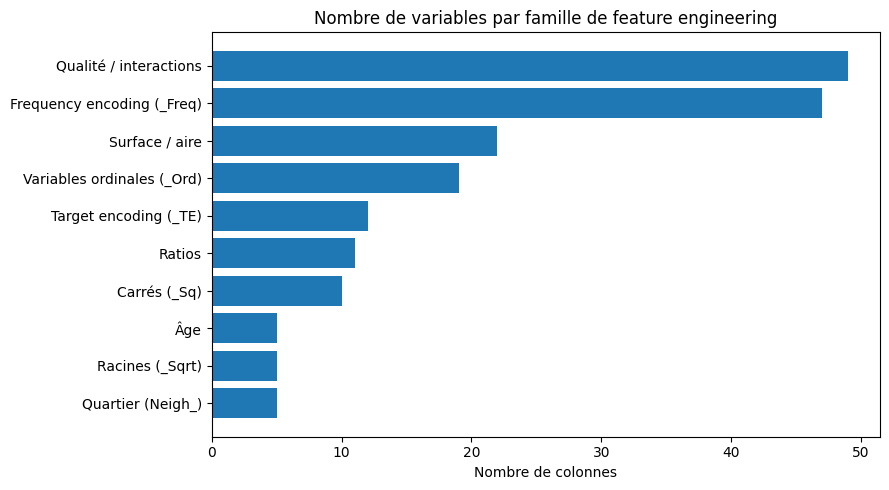

Interprétation : cette vue montre comment le notebook enrichit les données brutes avec plusieurs familles de signaux utiles aux modèles.


In [11]:
# ── Analyse des familles de variables créées ─────────────────────────────────
patterns = {
    'Target encoding (_TE)': '_TE',
    'Frequency encoding (_Freq)': '_Freq',
    'Variables ordinales (_Ord)': '_Ord',
    'Carrés (_Sq)': '_Sq',
    'Racines (_Sqrt)': '_Sqrt',
    'Quartier (Neigh_)': 'Neigh_',
    'Qualité / interactions': 'Qual',
    'Surface / aire': 'SF',
    'Âge': 'Age',
    'Ratios': 'Ratio',
}

family_counts = []
for family, pattern in patterns.items():
    family_counts.append({
        'Famille': family,
        'Nombre de colonnes': int(sum(pattern in c for c in X.columns))
    })

family_df = pd.DataFrame(family_counts).sort_values('Nombre de colonnes', ascending=True)
display(family_df.sort_values('Nombre de colonnes', ascending=False))

plt.figure(figsize=(9, 5))
plt.barh(family_df['Famille'], family_df['Nombre de colonnes'])
plt.title('Nombre de variables par famille de feature engineering')
plt.xlabel('Nombre de colonnes')
plt.tight_layout()
plt.show()

print("Interprétation : cette vue montre comment le notebook enrichit les données brutes avec plusieurs familles de signaux utiles aux modèles.")

,Feature,Corrélation
78,OverallQual_TotalSF,0.8939
93,NeighborhoodQual_TotalSF,0.8939
88,TotalQual_TotalSF,0.8834
87,ExterQual_TotalSF,0.8762
79,OverallQual_GrLivArea,0.8562
86,KitchenQual_GrLivArea,0.8340
108,TotalSF_Sqrt,0.8286
82,OverallQual_YearBuilt,0.8279
80,OverallQual_TotalBath,0.8257
52,TotalSF,0.8228


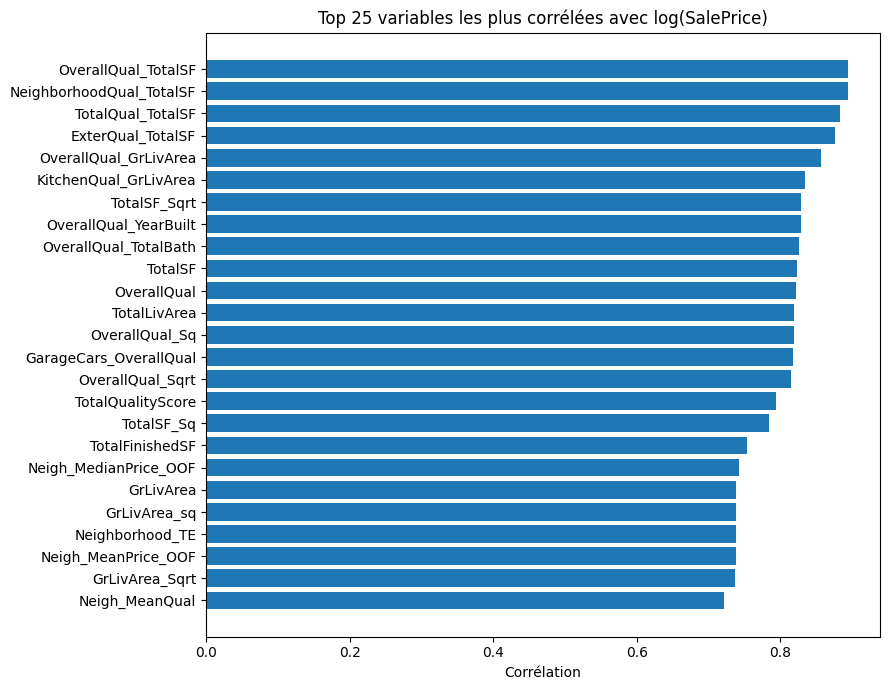

Interprétation : les variables liées à la qualité, à la surface et au quartier apparaissent souvent parmi les plus fortes, ce qui confirme la logique métier du feature engineering.


In [12]:
# ── Variables les plus corrélées avec log(SalePrice) ─────────────────────────
# On calcule la corrélation uniquement sur le train, car y n'existe pas pour le test.
correlations = []
for c in X.columns:
    values = X[c]
    if values.nunique(dropna=False) <= 1:
        continue
    corr = np.corrcoef(values.astype(float), y.astype(float))[0, 1]
    if np.isfinite(corr):
        correlations.append((c, corr, abs(corr)))

corr_df = pd.DataFrame(correlations, columns=['Feature', 'Corrélation', 'Corrélation absolue']) \
    .sort_values('Corrélation absolue', ascending=False)

top_corr = corr_df.head(25).copy()
display(top_corr[['Feature', 'Corrélation']])

plt.figure(figsize=(9, 7))
plot_df = top_corr.sort_values('Corrélation')
plt.barh(plot_df['Feature'], plot_df['Corrélation'])
plt.title('Top 25 variables les plus corrélées avec log(SalePrice)')
plt.xlabel('Corrélation')
plt.tight_layout()
plt.show()

print("Interprétation : les variables liées à la qualité, à la surface et au quartier apparaissent souvent parmi les plus fortes, ce qui confirme la logique métier du feature engineering.")

,Feature,Moyenne train,Moyenne test,Écart standardisé
28,GrLivArea_Sq,"2,539,270.2500","2,443,945.2500",0.0515
18,Neigh_MedianPrice_OOF,12.0257,12.0105,0.0503
11,TotalLivArea,14.8470,14.8033,0.0443
2,TotalQual_TotalSF,28.7481,28.6466,0.0441
23,GrLivArea_Sqrt,38.3439,38.0682,0.0435
9,TotalSF,14.8395,14.7983,0.0417
20,GrLivArea_sq,52.5868,52.3454,0.0411
6,TotalSF_Sqrt,49.9992,49.6922,0.0406
19,GrLivArea,13.1864,13.1479,0.0392
22,Neigh_MeanPrice_OOF,12.0210,12.0119,0.0384


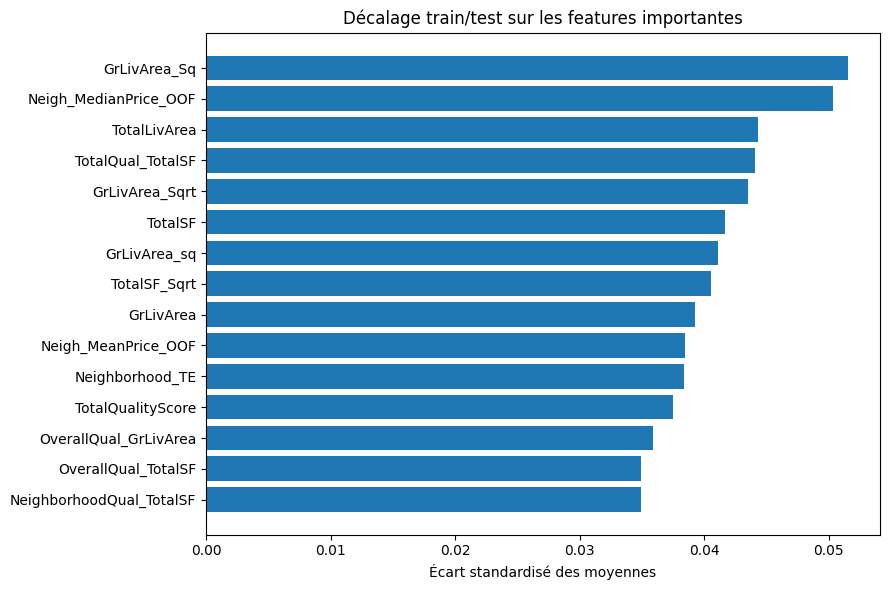

Interprétation : un écart élevé peut indiquer que certaines variables n'ont pas exactement la même distribution entre train et test. Ce n'est pas forcément une erreur, mais c'est utile à surveiller.


In [13]:
# ── Comparaison train vs test sur les variables numériques les plus importantes ─
# Objectif : détecter de gros décalages de distribution entre train et test.
important_features = corr_df.head(30)['Feature'].tolist()
shift_rows = []

for c in important_features:
    train_mean = float(X[c].mean())
    test_mean = float(X_sub[c].mean())
    train_std = float(X[c].std())
    standardized_gap = abs(train_mean - test_mean) / (train_std + 1e-6)
    shift_rows.append({
        'Feature': c,
        'Moyenne train': train_mean,
        'Moyenne test': test_mean,
        'Écart standardisé': standardized_gap,
    })

shift_df = pd.DataFrame(shift_rows).sort_values('Écart standardisé', ascending=False)
display(shift_df.head(15))

plt.figure(figsize=(9, 6))
plot_shift = shift_df.head(15).sort_values('Écart standardisé')
plt.barh(plot_shift['Feature'], plot_shift['Écart standardisé'])
plt.title('Décalage train/test sur les features importantes')
plt.xlabel('Écart standardisé des moyennes')
plt.tight_layout()
plt.show()

print("Interprétation : un écart élevé peut indiquer que certaines variables n'ont pas exactement la même distribution entre train et test. Ce n'est pas forcément une erreur, mais c'est utile à surveiller.")

,Taux de zéros dans X
count,444.0000
mean,0.5393
std,0.4392
min,0.0000
25%,0.0000
50%,0.7246
75%,0.9672
max,0.9993


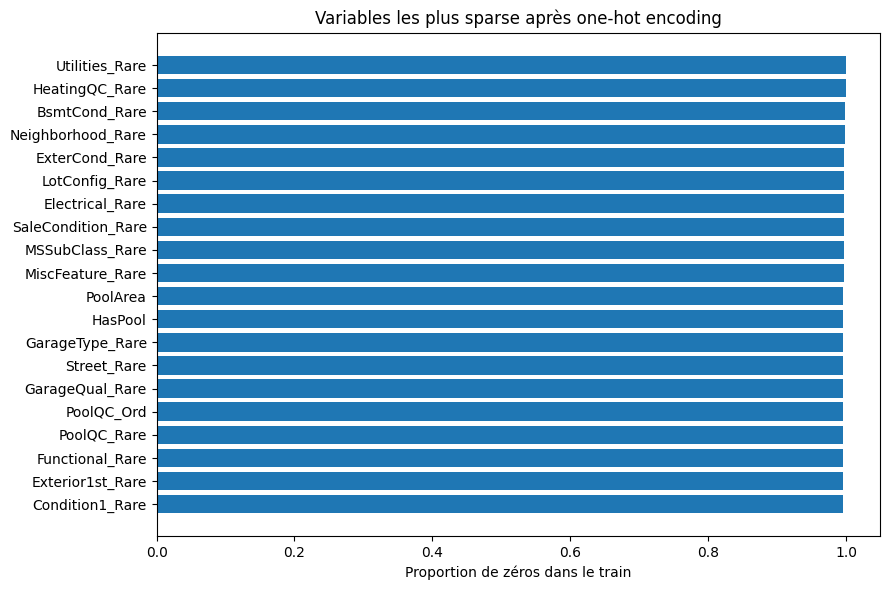

Interprétation : une forte sparsité est normale après one-hot encoding. Les modèles de boosting et les modèles linéaires régularisés savent généralement gérer ce type de matrice.


In [ ]:

# Après one-hot encoding, beaucoup de colonnes contiennent surtout des zéros.
zero_rate = (X == 0).mean().sort_values(ascending=False)
zero_summary = zero_rate.describe().to_frame('Taux de zéros dans X')
display(zero_summary)

top_sparse = zero_rate.head(20).sort_values()
plt.figure(figsize=(9, 6))
plt.barh(top_sparse.index, top_sparse.values)
plt.title('Variables les plus sparse après one-hot encoding')
plt.xlabel('Proportion de zéros dans le train')
plt.tight_layout()
plt.show()

print("Interprétation : une forte sparsité est normale après one-hot encoding. Les modèles de boosting et les modèles linéaires régularisés savent généralement gérer ce type de matrice.")

## 10. Synthèse du notebook 03

Ce notebook a produit une matrice finale beaucoup plus riche que les données brutes.

### Ce qui a été fait

- Création de variables de surface, âge, qualité, ratios et interactions.
- Ajout de signaux de quartier.
- Encodage des variables catégorielles par fréquence, target encoding OOF et one-hot encoding.
- Correction des distributions très asymétriques.
- Nettoyage final pour obtenir une matrice numérique stable.

### Pourquoi c'est important

Les modèles du notebook 04 ne voient pas directement une maison comme un humain. Le feature engineering aide donc les modèles à capter des idées plus proches de la réalité :

- une grande surface vaut plus si la qualité est élevée ;
- le quartier influence fortement le prix ;
- l'âge doit être interprété avec la rénovation ;
- les équipements comme le garage ou le sous-sol ajoutent de l'information ;
- les catégories rares doivent être traitées pour éviter le bruit.

### Fichier généré

```text
house_prices_stage2_features.pkl
```

Notebook suivant :

```text
04_models_predictions_house_prices_local.ipynb
```